<a href="https://colab.research.google.com/github/toshi039a/retail-demand-forecast/blob/main/%E9%9B%A2%E8%84%B1%E4%BA%88%E6%B8%ACPF_20260427.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EC顧客データを用いた離脱予測モデル構築

## 1. 概要とデータ読み込み

本分析では、Kaggleの「Ecommerce Customer Churn Analysis and Prediction」データセットを使用する。

本データは、ECサービスにおける顧客属性・利用状況・購買行動に関するデータであり、顧客が離脱するかどうかを予測することを目的とする。

顧客離脱予測は、既存顧客の維持・売上機会の損失防止・マーケティング施策の最適化において重要な分析テーマである。  
離脱リスクの高い顧客を事前に把握できれば、クーポン配布、サポート強化、利用促進施策などの打ち手につなげることができる。

なお、本データセットでは `Churn` は顧客離脱フラグとして提供されているが、離脱の具体的な定義は明記されていない。  
そのため、本分析では `Churn=1` を「ECサービスから離脱したと判定された顧客」、`Churn=0` を「継続顧客」として扱う。

本Notebookでは、以下の流れで離脱予測モデルを構築する。

1. 概要とデータ読み込み
2. 探索的データ分析（EDA）
3. 前処理と特徴量整理
4. モデリング・評価・モデル解釈
5. 閾値調整と施策提案
6. まとめ

### 1.1 データ構造の確認

まずは、データの行数・列数・カラムの型、欠損値の有無を確認する。

本データは顧客単位のデータであり、1行が1顧客を表す。  
目的変数は `Churn` であり、その他のカラムには顧客属性・利用状況・購買行動に関する情報が含まれている。

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 本分析ではKaggleの「Ecommerce Customer Churn Analysis and Prediction」を使用した。
# ECサービスの顧客属性・利用状況・購買行動に関するデータであり、
# 顧客が離脱するかどうかを予測する二値分類問題として扱う。
# データは以下から取得可能である。
# https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/離脱予測PF/E Commerce Dataset.xlsx'

df = pd.read_excel(file_path, sheet_name='E Comm')
data_dict = pd.read_excel(file_path, sheet_name='Data Dict')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

データは5,630行・20列で構成されている。  
数値変数とカテゴリ変数が混在しており、一部の数値変数には欠損値が存在する。

特に、以下のようなカラムに欠損値が確認される。

- `Tenure`
- `WarehouseToHome`
- `HourSpendOnApp`
- `OrderAmountHikeFromlastYear`
- `CouponUsed`
- `OrderCount`
- `DaySinceLastOrder`

これらの欠損値については、後続の前処理で適切に処理する。

### 1.2 カラム定義の確認

`Data Dict` シートには、各カラムの説明が記載されている。  
EDAやモデル解釈を行う前に、各変数の意味を確認する。

In [8]:
data_dict

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Data,Variable,Discerption
1,NaN,E Comm,CustomerID,Unique customer ID
2,NaN,E Comm,Churn,Churn Flag
3,NaN,E Comm,Tenure,Tenure of customer in organization
4,NaN,E Comm,PreferredLoginDevice,Preferred login device of customer
5,NaN,E Comm,CityTier,City tier
6,NaN,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
7,NaN,E Comm,PreferredPaymentMode,Preferred payment method of customer
8,NaN,E Comm,Gender,Gender of customer
9,NaN,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...


本分析で特に重要と思われる主なカラムは以下の通りである。

- `Churn`：顧客離脱フラグ
- `Tenure`：顧客の利用期間
- `SatisfactionScore`：満足度スコア
- `Complain`：クレーム有無
- `OrderCount`：直近月の注文回数
- `DaySinceLastOrder`：最終注文からの日数
- `CashbackAmount`：キャッシュバック金額

なお、`CustomerID` は顧客識別用のIDであり、予測に直接使用しない。

### 1.3 目的変数の確認

本分析の目的変数である `Churn` の分布を確認する。

離脱予測では、離脱顧客が継続顧客より少ないケースが多いため、まずはクラス比率を確認する。  
クラス不均衡がある場合、Accuracyだけでは少数派である離脱顧客の検出性能を適切に評価できない。

そのため、後続のモデル評価では、Precision、Recall、F1-score、ROC-AUC、PR-AUCを確認する。  
特に本分析では、離脱顧客の見逃しを抑えるためRecallを重視しつつ、施策対象が過剰にならないようPrecisionとのバランスも確認する。

In [9]:
# 目的変数の件数確認
df['Churn'].value_counts()

,count
Churn,
0,4682
1,948


In [13]:
# 離脱率の確認
churn_rate = df['Churn'].mean()

print(f'離脱率: {churn_rate:.2%}')

離脱率: 16.84%


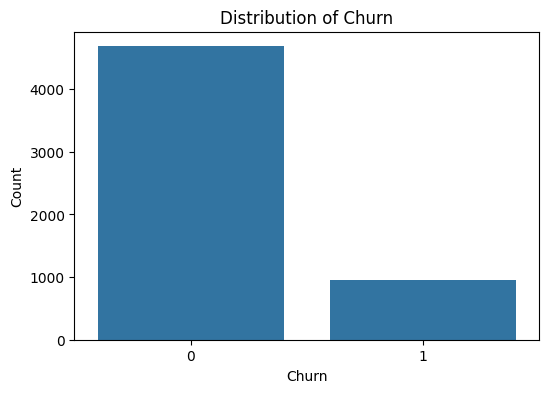

In [14]:
# Churnの分布を可視化
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

- `Churn` の分布を確認したところ、離脱率は16.84%であり、継続顧客が多数を占めている。

- このことから、本データはクラス不均衡を含む二値分類問題であると考えられる。  
- そのため、後続のモデル評価ではAccuracyだけでなく、RecallやPrecision、PR-AUCなども重視する。

### 1.4 欠損値の詳細確認

`df.info()` により、一部の数値変数に欠損値が存在することが確認された。

ここでは、各カラムの欠損数と欠損率を確認し、後続の前処理方針を検討する。

In [23]:
# 欠損数と欠損率を確認
missing_df = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_rate': df.isna().mean()
}).sort_values('missing_count', ascending=False)

# 欠損値があるカラムのみ表示
missing_df = missing_df[missing_df['missing_count'] > 0].copy()
missing_df

,missing_count,missing_rate
DaySinceLastOrder,307,0.054529
OrderAmountHikeFromlastYear,265,0.047069
Tenure,264,0.046892
OrderCount,258,0.045826
CouponUsed,256,0.045471
HourSpendOnApp,255,0.045293
WarehouseToHome,251,0.044583


- 欠損値を確認したところ、7つの数値変数に欠損が存在していることが分かった。
- 最も欠損が多い `DaySinceLastOrder` でも欠損率は5.45%であり、全体として欠損率は高くない。
- 欠損率が極端に高いカラムはないため、カラム削除ではなく補完によって対応する方針とする。
- 後続の前処理では、数値変数の欠損値を中央値で補完する。

### 1.5 数値変数・カテゴリ変数の整理

モデル構築に向けて、数値変数とカテゴリ変数を整理する。

本データには、利用期間・注文回数・満足度・クレーム有無などの数値変数と、ログイン端末・支払い方法・性別・注文カテゴリ・婚姻状況などのカテゴリ変数が含まれている。

後続の前処理では、数値変数には欠損値補完を行い、カテゴリ変数にはエンコーディングを行う。

In [24]:
# 数値変数の抽出
num_cols = df.select_dtypes(include=np.number).columns.tolist()

num_cols

['CustomerID',
 'Churn',
 'Tenure',
 'CityTier',
 'WarehouseToHome',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'SatisfactionScore',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

In [26]:
# カテゴリ変数の抽出
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

cat_cols

['PreferredLoginDevice',
 'PreferredPaymentMode',
 'Gender',
 'PreferedOrderCat',
 'MaritalStatus']

In [27]:
# カテゴリ変数のユニーク数確認
df[cat_cols].nunique()

,0
PreferredLoginDevice,3
PreferredPaymentMode,7
Gender,2
PreferedOrderCat,6
MaritalStatus,3


In [28]:
# 各カテゴリ変数の値を確認
for col in cat_cols:
    print(f'【{col}】')
    print(df[col].value_counts(dropna=False))
    print('-' * 50)

【PreferredLoginDevice】
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
--------------------------------------------------
【PreferredPaymentMode】
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
--------------------------------------------------
【Gender】
Gender
Male      3384
Female    2246
Name: count, dtype: int64
--------------------------------------------------
【PreferedOrderCat】
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
--------------------------------------------------
【MaritalStatus】
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64
---------------

- 数値変数とカテゴリ変数を確認したところ、本データには両方のタイプの特徴量が含まれている。
- カテゴリ変数には、ログイン端末、支払い方法、性別、主な注文カテゴリ、婚姻状況が含まれている。
- カテゴリ変数はいずれもユニーク数が多すぎず、後続の前処理ではOne-Hot Encodingで扱いやすい構成である。
- `PreferredLoginDevice` では `Mobile Phone` と `Phone`、`PreferredPaymentMode` では `Credit Card` と `CC`、`COD` と `Cash on Delivery` のように、意味が近いカテゴリが存在している。
- ただし、本データセット上でこれらが完全に同一カテゴリであるとは明記されていないため、本分析では元データのカテゴリを大きく加工せず、前処理でエンコーディングを行う方針とする。（実務ではこれらが同一カテゴリかどうかを、データ定義や業務担当者への確認によって判断し、必要に応じて表記ゆれの統一を行う）
- `CustomerID` は顧客識別用のIDであり、予測に直接使用しない。
- `Churn` は目的変数であるため、説明変数からは除外する。